In [1]:
!pip install langchain langchain_core langchain_community langgraph langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [3]:
from google.colab import userdata
import os
os.environ["GOOGLE_API_KEY"] = userdata.get("googleapikey")

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)

In [6]:
model.invoke("aur bhai kya haal chal")

AIMessage(content='Mai theek hoon, aap bataiye aapke kya haal hain? Sab badhiya chal raha hai?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de3f4-8f3b-7533-b0b3-3d0d4877599c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 443, 'total_tokens': 450, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 421}})

In [7]:
from typing_extensions import TypedDict
class State(TypedDict):
  application: str
  experience_level: str
  skill_match: str
  response: str

In [9]:
from langchain_core.prompts import ChatPromptTemplate

In [53]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)

def categorize_experience(state: State) -> State:
  print("\nCategorizing the experience level of the candidate : ")
  prompt = ChatPromptTemplate.from_template(
      "Based on the following job application, cateogorize the candidate as 'Entry-level', 'Mid-Level' or 'Senior-level' and dont asnwer extra things just the experience level"
      "Application: {application}"
  )

  chain = prompt | model
  experience_level = chain.invoke({"application": state["application"]}).content
  print(f"Experience Level : {experience_level}")
  return {"experience_level" : experience_level}

def assess_skillset(state: State) -> State:
  print("\nAssessing the skillset of the candidate : ")
  prompt = ChatPromptTemplate.from_template(
      "Based on the following job application for full stack developer, assess the candidate's skillset"
      "Respond with either 'Match' or 'No Match' based on the candidate's skillset"
      "Application: {application}"
  )
  chain = prompt | model
  skill_match = chain.invoke({"application": state["application"]}).content
  print(f"Skill Match : {skill_match}")
  return {"skill_match" : skill_match}

def schedule_interview(state: State) -> State:
  print("\nScheduling the interview : ")
  return {"response" : "Candidate has been shortlisted for an HR interview"}

def escalate_to_recruiter(state: State) -> State:
  print("\nEscalating the candidate to the recruiter : ")
  return {"response" : "Candidate has good experience but doesnt match job skills"}

def reject_candidate(state: State) -> State:
  print("\nRejecting the candidate : ")
  return {"response" : "Candidate doesnt match job skills"}

In [54]:
def route_app(state: State) -> str:
  if state["skill_match"] == "Match":
    return "schedule_interview"
  elif state["experience_level"] == "Senior-level":
    return "escalate_to_recruiter"
  else:
    return "reject_candidate"


In [55]:
workflow.add_node("categorize_experience", categorize_experience)
workflow.add_node("assess_skillset", assess_skillset)
workflow.add_node("schedule_interview", schedule_interview)
workflow.add_node("escalate_to_recruiter", escalate_to_recruiter)
workflow.add_node("reject_candidate", reject_candidate)

workflow.add_edge(START, "categorize_experience")
workflow.add_edge("categorize_experience", "assess_skillset")
workflow.add_conditional_edges("assess_skillset", route_app)
workflow.add_edge("schedule_interview", END)
workflow.add_edge("escalate_to_recruiter", END)
workflow.add_edge("reject_candidate", END)

In [56]:
app = workflow.compile()

In [35]:
pip install pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pygraphviz
Failed to build pygraphviz
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pygraphviz)


In [36]:
!sudo apt-get install graphviz graphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main a

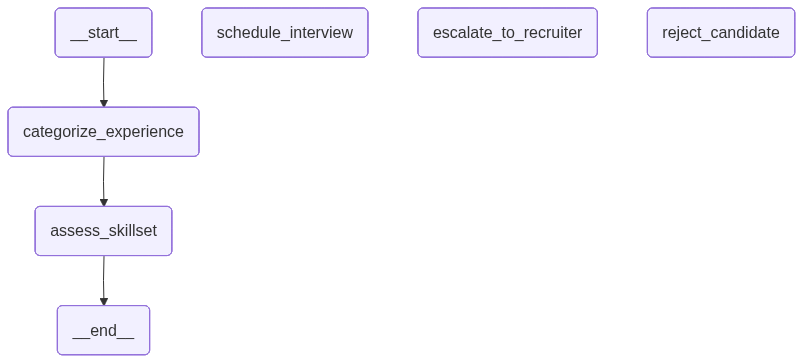

In [46]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [57]:
def run_candidate_screening(application: str):
  results = app.invoke({"application": application})
  print(results)

In [62]:
application_text = "I have 1 year of experience in full stack developement in react.js and FASTAPI"

In [63]:
result = run_candidate_screening(application_text)


Categorizing the experience level of the candidate : 
Experience Level : Entry-level

Assessing the skillset of the candidate : 
Skill Match : Match

Scheduling the interview : 
{'application': 'I have 1 year of experience in full stack developement in react.js and FASTAPI', 'experience_level': 'Entry-level', 'skill_match': 'Match', 'response': 'Candidate has been shortlisted for an HR interview'}
